In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [ ]:
# --- Load and prepare data ---
df = pd.read_csv("assets/data.csv")

# Combine YEAR, MO, DY to datetime
df['DATE'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MO'].astype(str) + '-' + df['DY'].astype(str))
df.sort_values('DATE', inplace=True)

# Filter data to use only 2003-2023 for training
train_df = df[df['DATE'].dt.year < 2024].copy()
print(f"Training data: {train_df['DATE'].min()} to {train_df['DATE'].max()}")

# Keep only GHI (ALLSKY_SFC_SW_DWN)
ghi_series = train_df['ALLSKY_SFC_SW_DWN'].ffill().values

# Normalize (optional, helps training)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
ghi_series_scaled = scaler.fit_transform(ghi_series.reshape(-1, 1)).flatten()

Training data: 2003-01-01 00:00:00 to 2023-12-30 00:00:00


In [ ]:
# --- Dataset setup ---
sequence_length = 7
train_size = int(len(ghi_series_scaled) * 0.8)

class SolarDataset(Dataset):
    def __init__(self, series, seq_len):
        self.X, self.y = [], []
        for i in range(len(series) - seq_len):
            self.X.append(series[i:i+seq_len])
            self.y.append(series[i+seq_len])
        # Convert to numpy array first, then to tensor for better performance
        self.X = torch.tensor(np.array(self.X), dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(np.array(self.y), dtype=torch.float32).unsqueeze(-1)

    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_series = ghi_series_scaled[:train_size]
val_series = ghi_series_scaled[train_size - sequence_length:]

train_dataset = SolarDataset(train_series, sequence_length)
val_dataset = SolarDataset(val_series, sequence_length)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1)

In [4]:
# --- Bayesian LSTM model ---
class BayesianLSTM(nn.Module):
    def __init__(self, hidden_dim=32, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc_mu = nn.Linear(hidden_dim, 1)
        self.fc_sigma = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        mu = self.fc_mu(out)
        sigma = torch.exp(self.fc_sigma(out))  # Ensures positivity
        return mu, sigma

model = BayesianLSTM()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Loss with uncertainty
def nll_loss(mu, sigma, y):
    return torch.mean((y - mu)**2 / (2 * sigma**2) + torch.log(sigma))

In [5]:
# --- Training ---
def train_model(model, loader, epochs=50):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for X, y in loader:
            optimizer.zero_grad()
            mu, sigma = model(X)
            loss = nll_loss(mu, sigma, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

train_model(model, train_loader)


Epoch 10, Loss: -1.9023
Epoch 20, Loss: -1.9212
Epoch 30, Loss: -1.9434
Epoch 40, Loss: -1.9562
Epoch 50, Loss: -1.9479


In [7]:
# --- Inference with dropout for uncertainty ---
def predict_with_uncertainty(model, loader, n_samples=100):
    model.train()  # Keep dropout active
    all_preds = []
    with torch.no_grad():
        for X, _ in loader:
            preds = [model(X)[0].item() for _ in range(n_samples)]
            all_preds.append(preds)
    return np.array(all_preds)
preds = predict_with_uncertainty(model, val_loader)

In [8]:
# Inverse Scale
mean_preds = scaler.inverse_transform(preds.mean(axis=1).reshape(-1, 1)).flatten() 
lower = scaler.inverse_transform(np.percentile(preds, 2.5, axis=1).reshape(-1, 1)).flatten() 
upper = scaler.inverse_transform(np.percentile(preds, 97.5, axis=1).reshape(-1, 1)).flatten() 
actuals = scaler.inverse_transform(val_series[sequence_length:].reshape(-1, 1)).flatten()

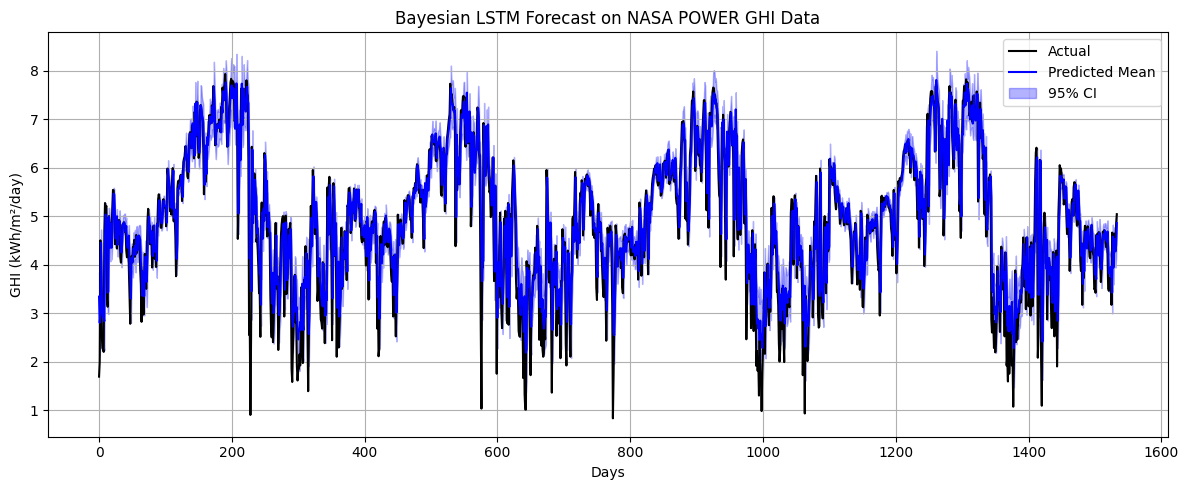

In [9]:
# --- Plot --- 
plt.figure(figsize=(12, 5)) 
plt.plot(actuals, label="Actual", color='black') 
plt.plot(mean_preds, label="Predicted Mean", color='blue') 
plt.fill_between(range(len(mean_preds)), lower, upper, color='blue', alpha=0.3, label="95% CI") 
plt.title("Bayesian LSTM Forecast on NASA POWER GHI Data") 
plt.xlabel("Days") 
plt.ylabel("GHI (kWh/m²/day)") 
plt.legend() 
plt.grid(True) 
plt.tight_layout() 
plt.show()

In [ ]:
# --- Save prediction results to CSV --- 
# # Create a DataFrame with the results 
results_df = pd.DataFrame({ 'Date': df['DATE'].iloc[train_size:].values[:len(mean_preds)], # Get corresponding dates 
                           'Actual': actuals, 'Predicted_Mean': mean_preds, 'Lower_CI': lower, 'Upper_CI': upper }) 
# Save to CSV 
results_df.to_csv('assets/prediction_results.csv', index=False) 
print(f"Prediction results saved to 'assets/prediction_results.csv'") 

# Calculate and print some evaluation metrics 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
mse = mean_squared_error(actuals, mean_preds) 
rmse = np.sqrt(mse) 
mae = mean_absolute_error(actuals, mean_preds) 
r2 = r2_score(actuals, mean_preds) 
print("\nModel Evaluation Metrics:") 
print(f"Mean Squared Error: {mse:.4f}") 
print(f"Root Mean Squared Error: {rmse:.4f}") 
print(f"Mean Absolute Error: {mae:.4f}") 
print(f"R² Score: {r2:.4f}")

Prediction results saved to 'prediction_results.csv'

Model Evaluation Metrics:
Mean Squared Error: 0.4797
Root Mean Squared Error: 0.6926
Mean Absolute Error: 0.4888
R² Score: 0.7687
